# Testing LP to QUBO Converter Plugin

This notebook demonstrates how to use the `quark-plugin-lp-to-qubo` converter to transform Linear Programs (LPs) into Quadratic Unconstrained Binary Optimization (QUBO) problems.

The converter supports:
- **Binary Integer Programs (BIPs)** — direct conversion
- **Continuous variables** — automatic discretisation via binary expansion
- **Constraints** — encoded as penalty terms in the QUBO objective

## Setup: Import Libraries

In [2]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt


def _find_workspace_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "QUARK-framework" / "src").exists() and (
            candidate / "quark-plugin-lp-to-qubo" / "src"
        ).exists():
            return candidate
    raise FileNotFoundError(
        "Could not find workspace root containing QUARK-framework/src and quark-plugin-lp-to-qubo/src"
    )


notebook_dir = Path.cwd()
workspace_root = _find_workspace_root(notebook_dir)
quark_framework_src = workspace_root / "QUARK-framework" / "src"
plugin_src = workspace_root / "quark-plugin-lp-to-qubo" / "src"

for path in (quark_framework_src, plugin_src):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

from quark.core import Data, Failed
from quark.interface_types.lp import LP
import quark_plugin_lp_to_qubo.lp_to_qubo as lp_to_qubo_module

# Reload so notebook reruns pick up local code edits without restarting kernel.
importlib.reload(lp_to_qubo_module)
LpToQuboConverter = lp_to_qubo_module.LpToQuboConverter

print("[OK] Added to sys.path:")
print(f"  - {quark_framework_src}")
print(f"  - {plugin_src}")

ModuleNotFoundError: No module named 'anytree'

## Example 1: Simple Binary Integer Program

Let's test with a simple BIP that minimizes `x + 2*y` subject to `x + y <= 1`.

In [49]:
# Define a simple BIP in LP format
lp_string_1 = """
Minimize
  obj: x + 2*y
Subject To
  c1: x + y <= 1
Bounds
  0 <= x <= 1
  0 <= y <= 1
Binaries
  x y
End
"""

print('LP Problem:')
print(lp_string_1)

LP Problem:

Minimize
  obj: x + 2*y
Subject To
  c1: x + y <= 1
Bounds
  0 <= x <= 1
  0 <= y <= 1
Binaries
  x y
End



In [50]:
# Create converter instance
converter = LpToQuboConverter(
    penalty_factor=1e6,
    continuous_var_precision=8
)

# Create LP object
lp = LP.from_str(lp_string_1)

# Convert to QUBO
result = converter.preprocess(lp)

if isinstance(result, Data):
    qubo = result.data
    print('✓ Conversion successful!')
    print(f'QUBO matrix shape: {qubo.as_matrix().shape}')
elif isinstance(result, Failed):
    print(f'✗ Conversion failed: {result.reason}')

✓ Conversion successful!
QUBO matrix shape: (2, 2)


In [51]:
# Display the QUBO matrix
qubo_matrix = qubo.as_matrix()
print('QUBO Matrix:')
print(qubo_matrix)
print()

# Display as dictionary
print('QUBO Dictionary representation:')
qubo_dict = qubo.as_dict()
for key, value in qubo_dict.items():
    if value != 0:  # Only show non-zero terms
        print(f'  {key}: {value:.6f}')

QUBO Matrix:
[[1.e+00 1.e+06]
 [1.e+06 2.e+00]]

QUBO Dictionary representation:
  q0: 1.000000
  q0,q1: 1000000.000000
  q1: 2.000000


In [52]:
# Display metrics
metrics = converter.get_metrics()
print('Conversion Metrics:')
for key, value in metrics.items():
    print(f'  {key}: {value}')

print()
print(f'Unique name: {converter.get_unique_name()}')

Conversion Metrics:
  runtime_s: 0.004484891891479492
  original_num_variables: 2
  discretised_num_variables: 2
  penalty_factor: 1000000.0
  continuous_var_precision: 8

Unique name: lp_to_qubo_pen1e+06_prec8


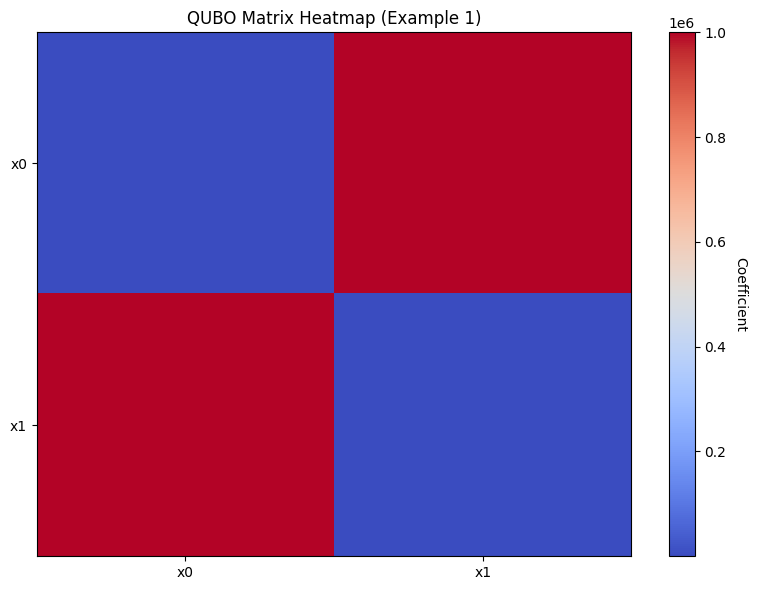

In [53]:
# Visualize the QUBO matrix as a heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(qubo_matrix, cmap='coolwarm', aspect='auto')

# Add labels
n_vars = qubo_matrix.shape[0]
var_labels = [f'x{i}' if i < 2 else f's{i-2}' for i in range(n_vars)]  # Assume first 2 are original vars
ax.set_xticks(range(n_vars))
ax.set_yticks(range(n_vars))
ax.set_xticklabels(var_labels)
ax.set_yticklabels(var_labels)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Coefficient', rotation=270, labelpad=15)

ax.set_title('QUBO Matrix Heatmap (Example 1)')
plt.tight_layout()
plt.show()

## Example 2: Larger BIP with More Constraints

Let's test with a slightly larger problem.

In [54]:
# Define a larger BIP
lp_string_2 = """
Minimize
  obj: x1 + 3*x2 + 2*x3 + x4
Subject To
  c1: x1 + x2 + x3 <= 2
  c2: 2*x2 + x3 + x4 <= 3
  c3: x1 + x4 >= 1
Bounds
  0 <= x1 <= 1
  0 <= x2 <= 1
  0 <= x3 <= 1
  0 <= x4 <= 1
Binaries
  x1 x2 x3 x4
End
"""

print('LP Problem:')
print(lp_string_2)

LP Problem:

Minimize
  obj: x1 + 3*x2 + 2*x3 + x4
Subject To
  c1: x1 + x2 + x3 <= 2
  c2: 2*x2 + x3 + x4 <= 3
  c3: x1 + x4 >= 1
Bounds
  0 <= x1 <= 1
  0 <= x2 <= 1
  0 <= x3 <= 1
  0 <= x4 <= 1
Binaries
  x1 x2 x3 x4
End



In [55]:
# Create a new converter instance
converter2 = LpToQuboConverter(
    penalty_factor=1e6,
    continuous_var_precision=8
)

# Convert
lp2 = LP.from_str(lp_string_2)
result2 = converter2.preprocess(lp2)

if isinstance(result2, Data):
    qubo2 = result2.data
    print('✓ Conversion successful!')
    print(f'QUBO matrix shape: {qubo2.as_matrix().shape}')
    print(f'Original variables: {converter2.original_num_variables}')
    print(f'After discretisation: {converter2.discretised_num_variables}')
elif isinstance(result2, Failed):
    print(f'✗ Conversion failed: {result2.reason}')

✓ Conversion successful!
QUBO matrix shape: (8, 8)
Original variables: 4
After discretisation: 4


In [56]:
# Display non-zero QUBO terms
qubo_matrix_2 = qubo2.as_matrix()
qubo_dict_2 = qubo2.as_dict()

print('Non-zero QUBO terms (top 20):')
non_zero_terms = [(k, v) for k, v in qubo_dict_2.items() if v != 0]
non_zero_terms.sort(key=lambda x: abs(x[1]), reverse=True)

for i, (key, value) in enumerate(non_zero_terms[:20]):
    print(f'  {key}: {value:.6f}')

if len(non_zero_terms) > 20:
    print(f'  ... and {len(non_zero_terms) - 20} more terms')

Non-zero QUBO terms (top 20):
  q1: -10999997.000000
  q1,q7: 8000000.000000
  q7: -8000000.000000
  q2: -7999998.000000
  q1,q2: 6000000.000000
  q3: -5999999.000000
  q6: -5000000.000000
  q1,q3: 4000000.000000
  q1,q6: 4000000.000000
  q2,q7: 4000000.000000
  q3,q7: 4000000.000000
  q6,q7: 4000000.000000
  q0: -3999999.000000
  q4: -3000000.000000
  q5: -3000000.000000
  q0,q1: 2000000.000000
  q0,q2: 2000000.000000
  q0,q4: 2000000.000000
  q0,q5: 2000000.000000
  q1,q4: 2000000.000000
  ... and 8 more terms


In [57]:
# Display metrics for example 2
metrics2 = converter2.get_metrics()
print('Conversion Metrics (Example 2):')
for key, value in metrics2.items():
    print(f'  {key}: {value}')

Conversion Metrics (Example 2):
  runtime_s: 0.005509853363037109
  original_num_variables: 4
  discretised_num_variables: 4
  penalty_factor: 1000000.0
  continuous_var_precision: 8


## Custom Test: Try Your Own LP

Edit the `my_lp_string` below and run the cell to test your own LP problem!

In [58]:
# Define your own LP problem
my_lp_string = """
Minimize
  obj: a + b + c
Subject To
  c1: a + b <= 1
  c2: b + c <= 1
Bounds
  0 <= a <= 1
  0 <= b <= 1
  0 <= c <= 1
Binaries
  a b c
End
"""

print('Your LP Problem:')
print(my_lp_string)

Your LP Problem:

Minimize
  obj: a + b + c
Subject To
  c1: a + b <= 1
  c2: b + c <= 1
Bounds
  0 <= a <= 1
  0 <= b <= 1
  0 <= c <= 1
Binaries
  a b c
End



In [59]:
# Convert your LP
converter_custom = LpToQuboConverter(
    penalty_factor=1e6,
    continuous_var_precision=8
)

lp_custom = LP.from_str(my_lp_string)
result_custom = converter_custom.preprocess(lp_custom)

if isinstance(result_custom, Data):
    qubo_custom = result_custom.data
    print('✓ Conversion successful!')
    print()
    print('QUBO Matrix:')
    print(qubo_custom.as_matrix())
    print()
    print('Metrics:')
    for key, value in converter_custom.get_metrics().items():
        print(f'  {key}: {value}')
elif isinstance(result_custom, Failed):
    print(f'✗ Conversion failed: {result_custom.reason}')

✓ Conversion successful!

QUBO Matrix:
[[1.e+00 1.e+06 0.e+00]
 [1.e+06 1.e+00 1.e+06]
 [0.e+00 1.e+06 1.e+00]]

Metrics:
  runtime_s: 0.004528999328613281
  original_num_variables: 3
  discretised_num_variables: 3
  penalty_factor: 1000000.0
  continuous_var_precision: 8


## Notes

### LP Format
The converter accepts LP problems in the standard LP format (CPLEX-style):
```
Minimize
  objective: expression
Subject To
  constraint_name: expression [<=|>=|=] rhs
  ...
Bounds
  lower <= var <= upper
  ...
Binaries
  var1 var2 ...
End
```

### Parameters
- **penalty_factor**: Controls how strictly constraints are enforced. Larger values = stricter enforcement.
- **continuous_var_precision**: Number of bits per continuous variable. Higher precision = larger QUBO but more accurate.

### QUBO Constraints
- All variables must be **binary** (or will be discretised)
- All constraints are encoded as **penalty terms** in the objective
- The resulting QUBO is always **symmetric**